**E-COMMERCE SALES ANALYSIS (CAPSTONE PROJECT)**

**MUNEEBA SALEEM**

**SUMMARY:**

E-Commerce Sales Analysis  demonstrates end-to-end data analytics workflow including data cleaning, transformation, exploratory analysis, and visualization using Python. The project extracts meaningful business insights from real-world transaction data to support data-driven decision-making.

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**pandas (pd) →** used for handling tables (dataset)

**numpy (np)→** used for numerical operations

**matplotlib.pyplot (plt)** → used for graphs and charts

**seaborn (sns) →** used for advanced, prettier visualizations

In [9]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


**Load Dataset**

In [11]:
import pandas as pd

df = pd.read_csv("data.csv", encoding="ISO-8859-1")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


**Dataset Overview**

In [17]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397924 non-null  object 
 1   StockCode    397924 non-null  object 
 2   Description  397924 non-null  object 
 3   Quantity     397924 non-null  int64  
 4   InvoiceDate  397924 non-null  object 
 5   UnitPrice    397924 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      397924 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


**df.shape** → tells rows & columns (size of dataset)

**df.info()** → shows:
column names

data types

missing values

**df.describe()** → gives statistics:

mean

min/max

standard deviation

**Data Cleaning**

Remove missing values

In [13]:
df.dropna(inplace=True)

Remove cancelled orders

In [18]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

Convert InvoiceDate to datetime

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Create Total Sales column

In [20]:
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

**Feature Engineering**

In [21]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day

**Exploratory Data Analysis (EDA)**

Daily Sales Trend

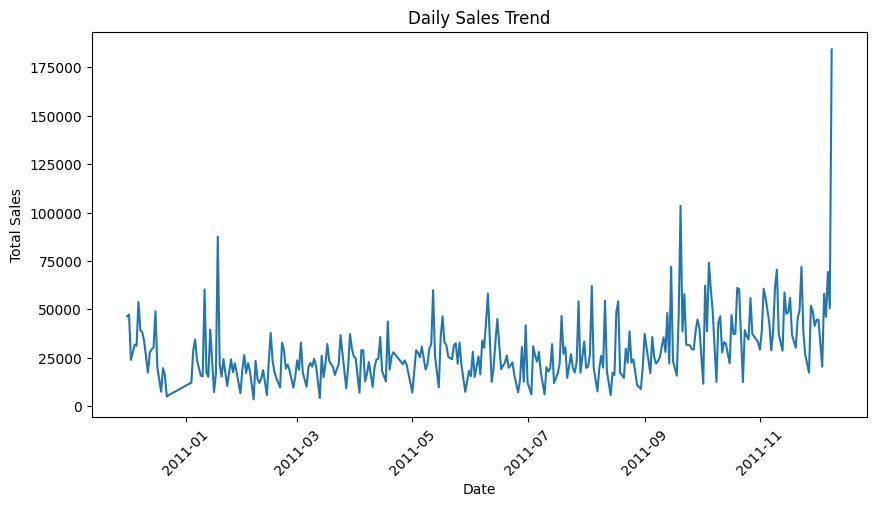

In [22]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalSales'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Top 10 Selling Products

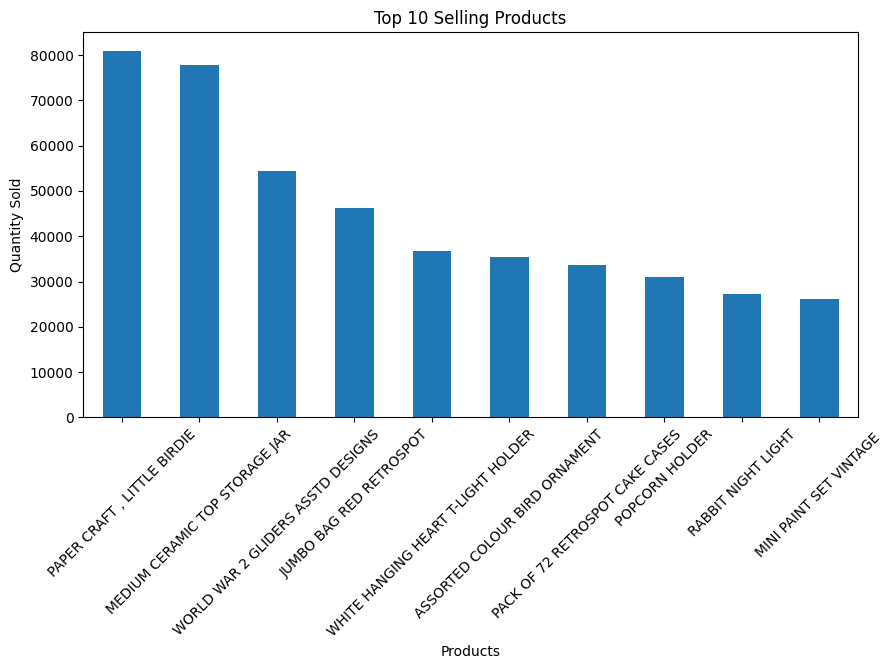

In [23]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

Top 10 Countries by Sales

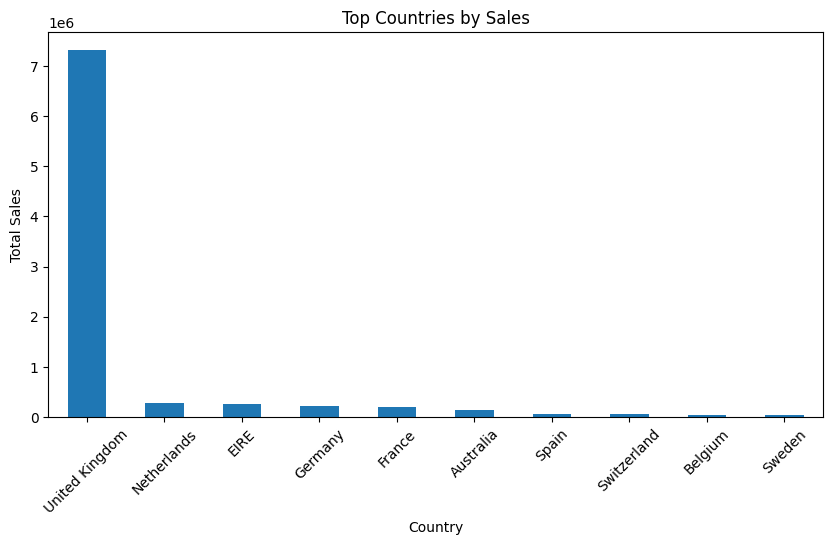

In [24]:
country_sales = df.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_sales.plot(kind='bar')
plt.title("Top Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Monthly Sales Trend

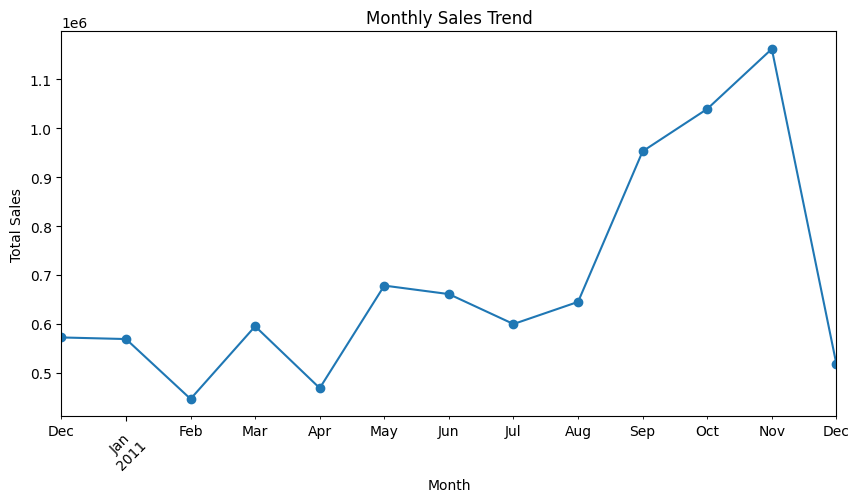

In [25]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalSales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Top Revenue Generating Products

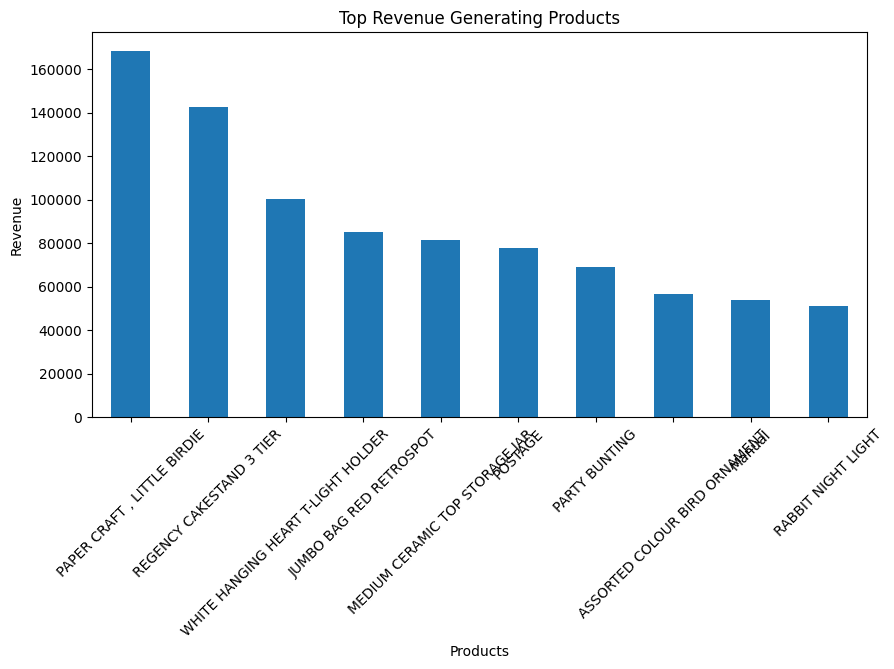

In [26]:
top_revenue = df.groupby('Description')['TotalSales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_revenue.plot(kind='bar')
plt.title("Top Revenue Generating Products")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Quantity Distribution

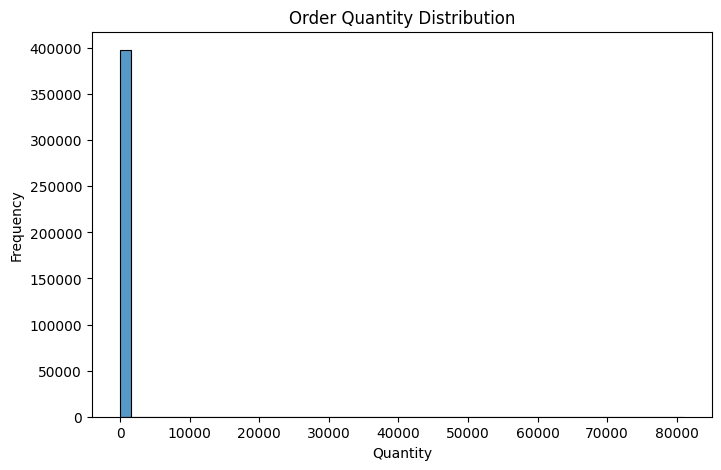

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=50)
plt.title("Order Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()